In [5]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))
from utils.Utils import (
    P_X_CMND,
    CanonicalUnits,
    GravitationalParameters
)
import numpy as np
import multimin as mm
from tqdm import tqdm
import matplotlib.pyplot as plt
import spiceypy as spy
import seaborn as sns
import plotly.graph_objects as go

In [3]:
deg = np.pi/180
AU_m = 1.496e11 #m
M_sun = 1.9891e30
G = 6.67430e-11 # m^3 / (kg s^2)
year = 365.25*24*3600 #s
mu = CanonicalUnits().mu
grav_params = GravitationalParameters(mu=mu)

C:\Users\aguju\Documents\tesis\juanita\juanita\repo\TesisRepo\jacobian_calculations\multimin.py:255: UserWarning: The figure layout has changed to tight
  self.fig.tight_layout()


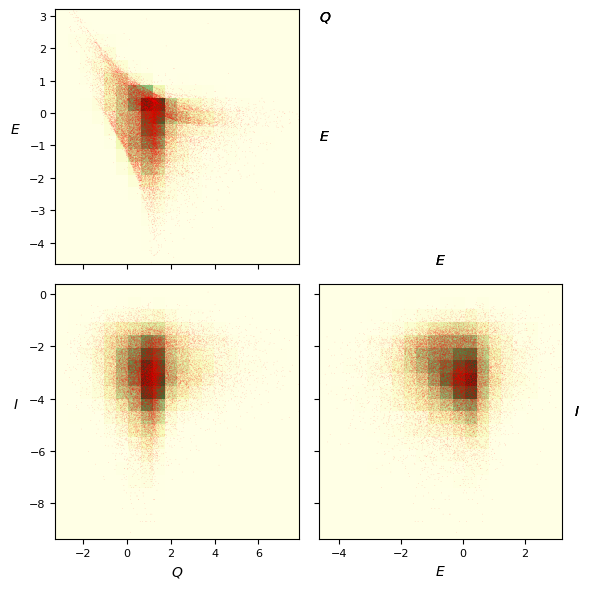

In [4]:
F = mm.FitCMND(f"../../multimin/products/fit-NEAs-qei-Ng10-Nv3-rad.pkl")

props=["Q","E","I"]
hargs=dict(bins=20,cmap='YlGn')
sargs=dict(s=0.2,edgecolor='None',color='r', alpha=0.3)
G=F.plotFit(props=props,hargs=hargs,sargs=sargs,figsize=3)

In [ ]:
xmin, xmax = (0.9039710143502464, 1.0960289856497536)
ymin, ymax = ( -0.09602898564975362, 0.09602898564975362)
zmin, zmax = (-0.09602898564975362, 0.09602898564975362)
vxmin, vxmax = (-0.5064245183055923, 0.5064245183055923)
vymin, vymax = (5.777598212496408, 6.790447249107593)
vzmin, vzmax = (-0.5064245183055923, 0.5064245183055923)

X = np.linspace(xmin, xmax, 100)
Y = np.linspace(ymin, ymax, 100)
Z = np.linspace(zmin, zmax, 100)
VX = np.linspace(vxmin, vxmax, 100)
VY = np.linspace(vymin, vymax, 100)
VZ = np.linspace(vzmin, vzmax, 100)

X_malla, Y_malla = np.meshgrid(X, Y)
X_malla, Z_malla = np.meshgrid(X, Z)
VX_malla, VY_malla = np.meshgrid(VX, VY)
VX_malla, VZ_malla = np.meshgrid(VX, VZ)

zero_vector = np.zeros_like(X_malla) + 0.1

P_XY = P_X_CMND(X_malla, Y_malla, z=zero_vector, vx=zero_vector, vy=zero_vector, vz=zero_vector, q_max=q_max, e_max=e_max, i_max=i_max, mu=mu, F=F)
P_XZ = P_X_CMND(X_malla, y=zero_vector, z=Z_malla, vx=zero_vector, vy=zero_vector, vz=zero_vector, q_max=q_max, e_max=e_max, i_max=i_max, mu=mu, F=F)
P_VXY = P_X_CMND(x=zero_vector, y=zero_vector, z=zero_vector, vx=VX_malla, vy=VY_malla, vz=zero_vector, mu=mu)
P_VXZ = P_X_CMND(x=zero_vector, y=zero_vector, z=zero_vector, vx=VX_malla, vy=zero_vector, vz=VZ_malla, mu=mu)